# Data Exploration — Kalimati Tarkari Dataset

This notebook performs an initial exploration of the Kalimati Tarkari vegetable and fruit price dataset. The goals are to:

- Understand the structure, size, and data types of the dataset
- Check data quality (missing values, duplicates)
- Explore the commodities and date coverage
- Visualize price distributions to inform later preprocessing, clustering, and forecasting steps

## 1. Import Libraries

In [1]:
# Import necessary libraries
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset

The raw dataset contains daily minimum, maximum, and average prices (in Kalimati market units) for 132 vegetable and fruit commodities, recorded between June 2013 and May 2021.

In [2]:
# Resolve the project root relative to this notebook, independent of the machine/OS it runs on
import os


def _find_project_root(marker=os.path.join("data", "raw", "kalimati_tarkari_dataset.csv")):
    path = os.getcwd()
    for _ in range(6):
        if os.path.exists(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            break
        path = parent
    raise FileNotFoundError(
        "Could not locate the project root (expected to find data/raw/kalimati_tarkari_dataset.csv "
        "within a few parent directories of the current working directory).")


PROJECT_ROOT = _find_project_root()
CSV_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "kalimati_tarkari_dataset.csv")

# Load the dataset
df = pd.read_csv(CSV_PATH)
df.head()

,SN,Commodity,Date,Unit,Minimum,Maximum,Average
0,0,Tomato Big(Nepali),2013-06-16,Kg,35.0,40.0,37.5
1,1,Tomato Small(Local),2013-06-16,Kg,26.0,32.0,29.0
2,2,Potato Red,2013-06-16,Kg,20.0,21.0,20.5
3,3,Potato White,2013-06-16,Kg,15.0,16.0,15.5
4,4,Onion Dry (Indian),2013-06-16,Kg,28.0,30.0,29.0


## 3. Initial Data Inspection

Check the dataset's shape, column names, and data types before doing any analysis.

In [3]:
# Basic data inspection
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

Shape of dataset: (197161, 7)

Column Names:
Index(['SN', 'Commodity', 'Date', 'Unit', 'Minimum', 'Maximum', 'Average'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197161 entries, 0 to 197160
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   SN         197161 non-null  int64  
 1   Commodity  197161 non-null  object 
 2   Date       197161 non-null  object 
 3   Unit       197161 non-null  object 
 4   Minimum    197161 non-null  float64
 5   Maximum    197161 non-null  float64
 6   Average    197161 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 10.5+ MB
None


### Date Column Conversion

`Date` is loaded as a string (`object`); convert it to `datetime64` so it can be used for time-series indexing, resampling, and seasonality analysis in later notebooks.

In [4]:
df['Date'].dtype.name

'object'

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
df['Date'].dtype.name

'datetime64[ns]'

## 4. Statistical Summary

Summarize the numerical price columns and the categorical columns (`Commodity`, `Unit`) separately.

In [7]:
# Statistical Summary
# Numerical summary
df.describe()

,SN,Date,Minimum,Maximum,Average
count,197161.000000,197161,197161.000000,197161.000000,197161.000000
mean,98580.000000,2017-08-09 09:02:22.695563520,85.423938,94.161284,89.792611
min,0.000000,2013-06-16 00:00:00,1.000000,6.000000,5.000000
25%,49290.000000,2015-08-24 00:00:00,40.000000,45.000000,42.500000
50%,98580.000000,2017-08-03 00:00:00,60.000000,70.000000,65.000000
75%,147870.000000,2019-08-27 00:00:00,100.000000,110.000000,105.000000
max,197160.000000,2021-05-13 00:00:00,1800.000000,2000.000000,1900.000000
std,56915.622549,NaN,77.058896,82.375858,79.619003


In [8]:
# Categorical summary
df.describe(include='object')

,Commodity,Unit
count,197161,197161
unique,132,4
top,Ginger,Kg
freq,2751,184408


## 5. Data Quality Checks

Verify there are no missing values or duplicate rows before proceeding to deeper analysis.

In [9]:
# Check missing values
missing_values = df.isnull().sum()

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing %": missing_percent
})

print(missing_df[missing_df["Missing Count"] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


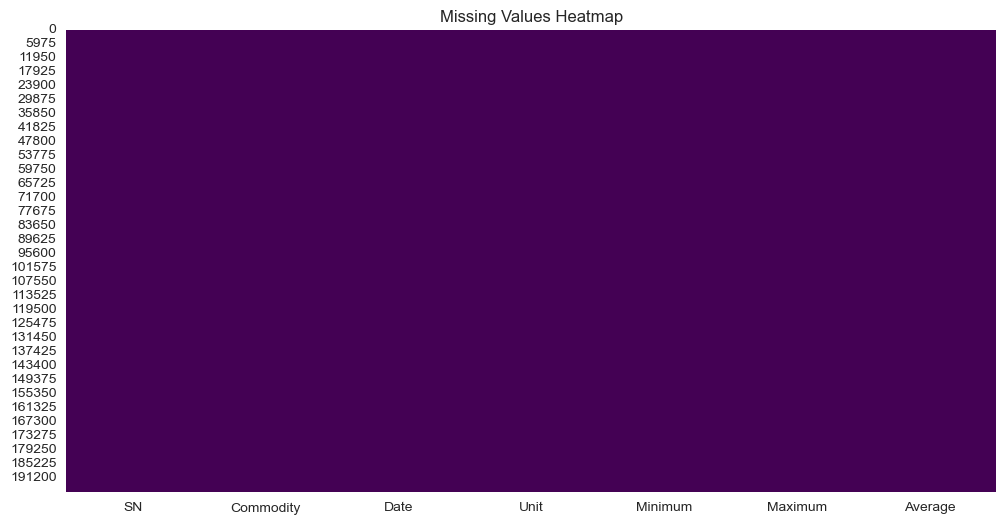

In [10]:
# Visualize missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [11]:
# Check for duplicates
duplicates = df.duplicated().sum()

print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 0


## 6. Commodity Analysis

Explore how many distinct commodities are tracked, how their record counts vary, and the overall date coverage of the dataset.

In [12]:
df["Commodity"].nunique()

132

In [13]:
sorted(df["Commodity"].unique())

['Apple(Fuji)',
 'Apple(Jholey)',
 'Arum',
 'Asparagus',
 'Bakula',
 'Bamboo Shoot',
 'Banana',
 'Barela',
 'Bauhania flower',
 'Bitter Gourd',
 'Bottle Gourd',
 'Brd Leaf Mustard',
 'Brinjal Long',
 'Brinjal Round',
 'Brocauli',
 'Cabbage',
 'Cabbage(Local)',
 'Cabbage(Terai)',
 'Capsicum',
 'Carrot(Local)',
 'Carrot(Terai)',
 'Cauli Local',
 'Cauli Local(Jyapu)',
 'Cauli Terai',
 'Celery',
 'Chilli Dry',
 'Chilli Green',
 'Chilli Green(Akbare)',
 'Chilli Green(Bullet)',
 'Chilli Green(Machhe)',
 'Christophine',
 'Clive Dry',
 'Clive Green',
 'Coriander Green',
 'Cow pea(Long)',
 'Cowpea(Short)',
 'Cress Leaf',
 'Cucumber(Hybrid)',
 'Cucumber(Local)',
 'Drumstick',
 'Fennel Leaf',
 'Fenugreek Leaf',
 'Fish Fresh',
 'Fish Fresh(Bachuwa)',
 'Fish Fresh(Chhadi)',
 'Fish Fresh(Mungari)',
 'Fish Fresh(Rahu)',
 'French Bean(Hybrid)',
 'French Bean(Local)',
 'French Bean(Rajma)',
 'Garlic Dry Chinese',
 'Garlic Dry Nepali',
 'Garlic Green',
 'Ginger',
 'Grapes(Black)',
 'Grapes(Green)',
 'Gr

In [14]:
df["Commodity"].value_counts()

Commodity
Ginger                  2751
Cauli Local             2750
Cabbage(Local)          2749
Chilli Dry              2748
Raddish White(Local)    2747
                        ... 
Maize                     24
Mango(Calcutte)           23
Sweet Lime                14
Musk Melon                10
Mango(Chousa)              2
Name: count, Length: 132, dtype: int64

### Date Range

In [15]:
print(df['Date'].min())
print(df['Date'].max())

2013-06-16 00:00:00
2021-05-13 00:00:00


In [16]:
# Count of dates for each commodity
df.groupby('Commodity')['Date'].count().sort_values(ascending=False)

Commodity
Ginger                  2751
Cauli Local             2750
Cabbage(Local)          2749
Chilli Dry              2748
Raddish White(Local)    2747
                        ... 
Maize                     24
Mango(Calcutte)           23
Sweet Lime                14
Musk Melon                10
Mango(Chousa)              2
Name: Date, Length: 132, dtype: int64

## 7. Visualizations

### Top Commodities by Record Count

In [17]:
commodity_counts = (
    df['Commodity']
    .value_counts()
    .head(15)
)

commodity_counts

Commodity
Ginger                  2751
Cauli Local             2750
Cabbage(Local)          2749
Chilli Dry              2748
Raddish White(Local)    2747
Potato Red              2746
Bamboo Shoot            2744
Banana                  2744
Brd Leaf Mustard        2742
Onion Dry (Indian)      2742
Tomato Small(Local)     2741
Coriander Green         2741
French Bean(Local)      2739
Brinjal Long            2736
Carrot(Local)           2736
Name: count, dtype: int64

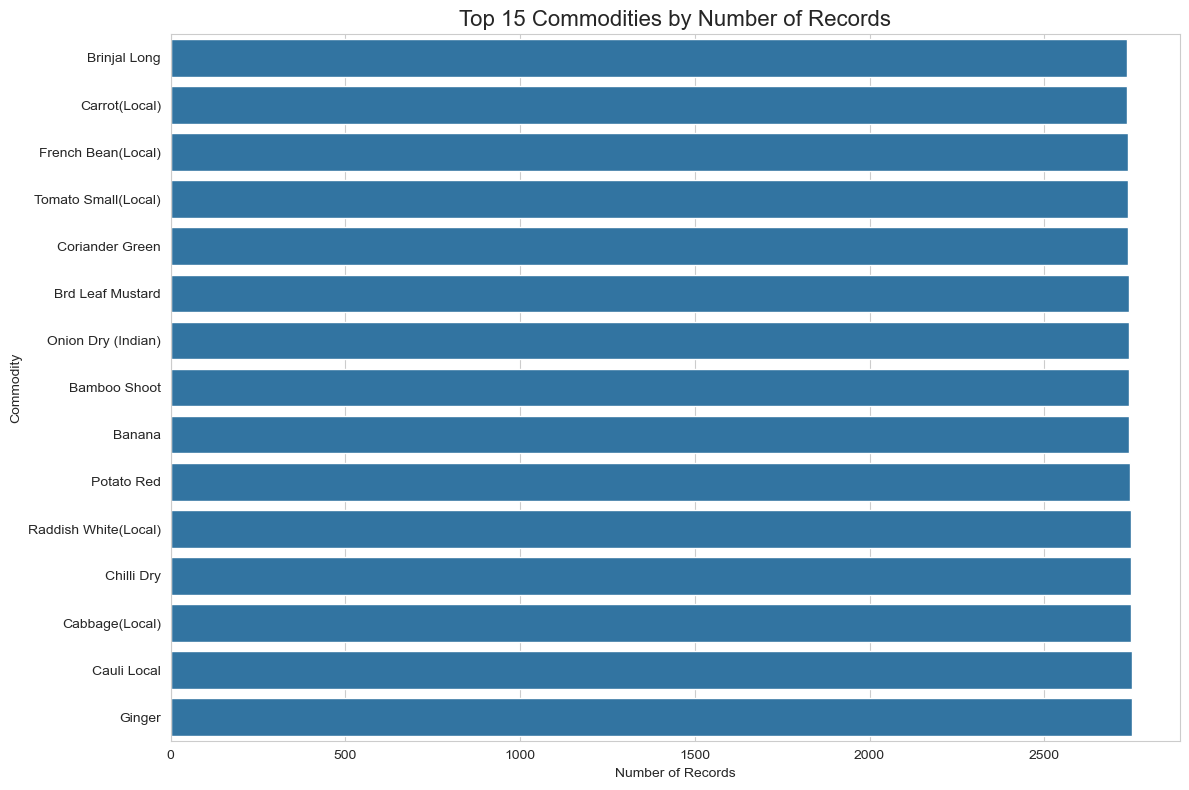

In [18]:
# Visualize the top 15 commodities by number of records
top_commodities = (
    df['Commodity']
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_commodities.values,
    y=top_commodities.index
)

plt.title(
    'Top 15 Commodities by Number of Records',
    fontsize=16
)

plt.xlabel('Number of Records')
plt.ylabel('Commodity')

plt.tight_layout()
plt.show()

### Price Distribution

`Average` price is heavily right-skewed (mean ≈ 89.8, but max = 1900), driven by a small number of high-value commodities. The histogram, boxplot, and violin plot below all illustrate this skew.

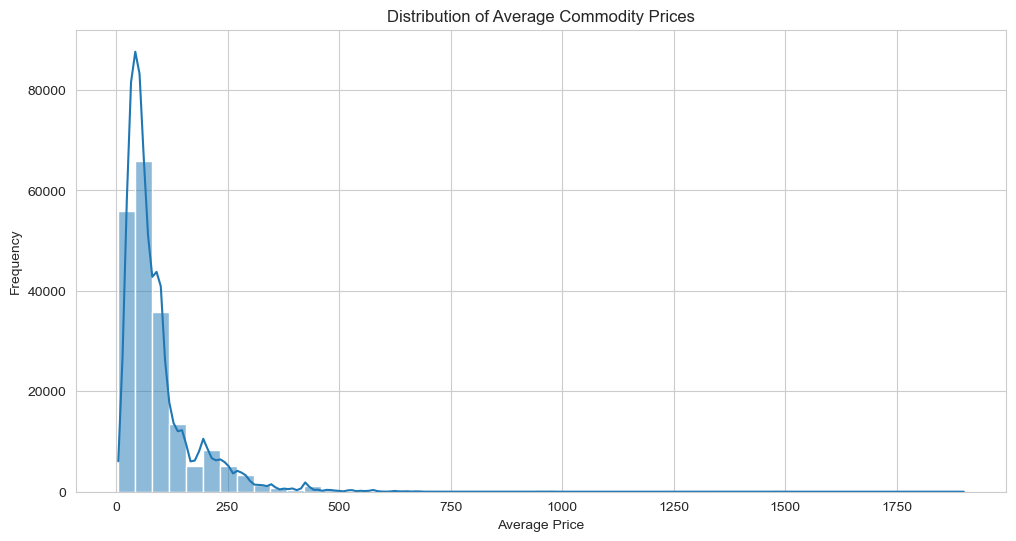

In [19]:
# Distribution of Average Prices
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='Average',
    bins=50,
    kde=True
)

plt.title('Distribution of Average Commodity Prices')
plt.xlabel('Average Price')
plt.ylabel('Frequency')

plt.show()

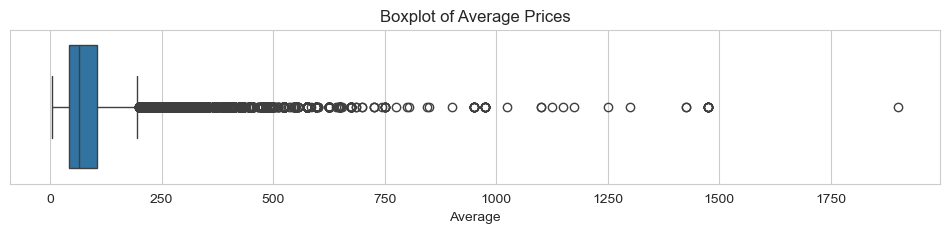

In [20]:
# Boxplot of Average Prices
plt.figure(figsize=(12,2))

sns.boxplot(
    x=df['Average']
)

plt.title('Boxplot of Average Prices')

plt.show()

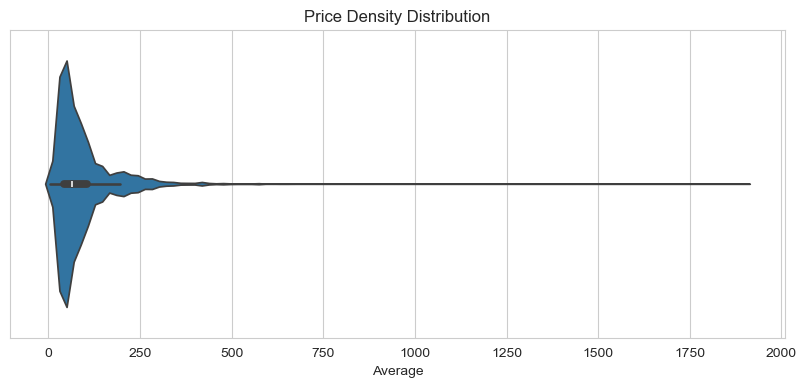

In [21]:
# Violin plot of Average Prices
plt.figure(figsize=(10,4))

sns.violinplot(
    x=df['Average']
)

plt.title('Price Density Distribution')

plt.show()

### Log-Transformed Price Distribution

Applying a `log1p` transform compresses the long right tail and makes the price distribution closer to normal — useful for models that assume normally distributed inputs.

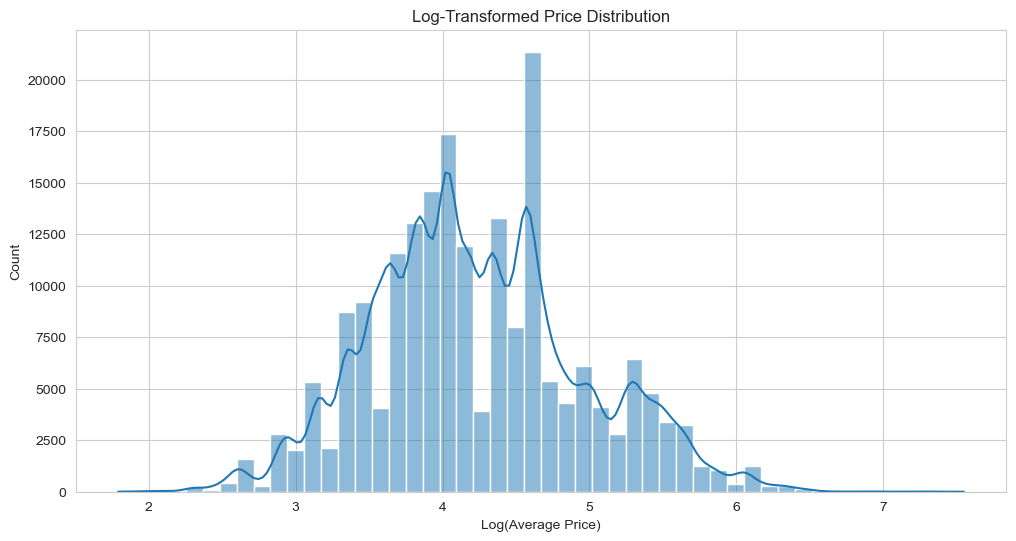

In [22]:
# Log Transformation of Average Prices
df['Log_Average'] = np.log1p(df['Average'])

plt.figure(figsize=(12,6))

sns.histplot(
    df['Log_Average'],
    bins=50,
    kde=True
)

plt.title('Log-Transformed Price Distribution')

plt.xlabel('Log(Average Price)')

plt.show()

## 8. Key Takeaways

- **Size**: 197,161 records spanning **132 commodities** from **2013-06-16 to 2021-05-13** (~8 years), with no missing values and no duplicate rows.
- **Coverage is uneven**: record counts per commodity range from 2 (Mango(Chousa)) to 2,751 (Ginger) — some commodities will have far too little history for reliable time-series modeling.
- **Units**: prices are recorded per `Kg` for the vast majority of records (184,408 of 197,161), with a few other units mixed in.
- **Prices are right-skewed**: `Average` price ranges from 5 to 1,900 with a mean of ~89.8; a `log1p` transform substantially normalizes the distribution.

**Next steps**: use [02_eda_seasonality_analysis.ipynb](02_eda_seasonality_analysis.ipynb) to explore trends and seasonality per commodity, and filter out commodities with insufficient history before clustering/forecasting.